# House Price Prediction using Machine Learning

##  Problem Statement
The goal of this project is to predict house prices based on features such as size, bedrooms, bathrooms, and other factors using regression models.

## Objective
- Perform data preprocessing
- Analyze data using visualization
- Train regression models
- Evaluate and compare model performance

In [3]:
# Importing required libraries for data manipulation, visualization, and ML

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LOAD THE DATASET

In [4]:
# Loading dataset into pandas dataframe

df = pd.read_csv("house_price_regression_dataset.csv")
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [5]:
# Checking dataset structure and summary

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


CHECKING FOR MISSING VALUES

In [7]:
# Checking missing values
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [11]:
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [15]:
df.columns = df.columns.str.lower()

**HISTOGRAM**

Histograms show the distribution of each features. We can observe whether data is skewed or normally distributed.

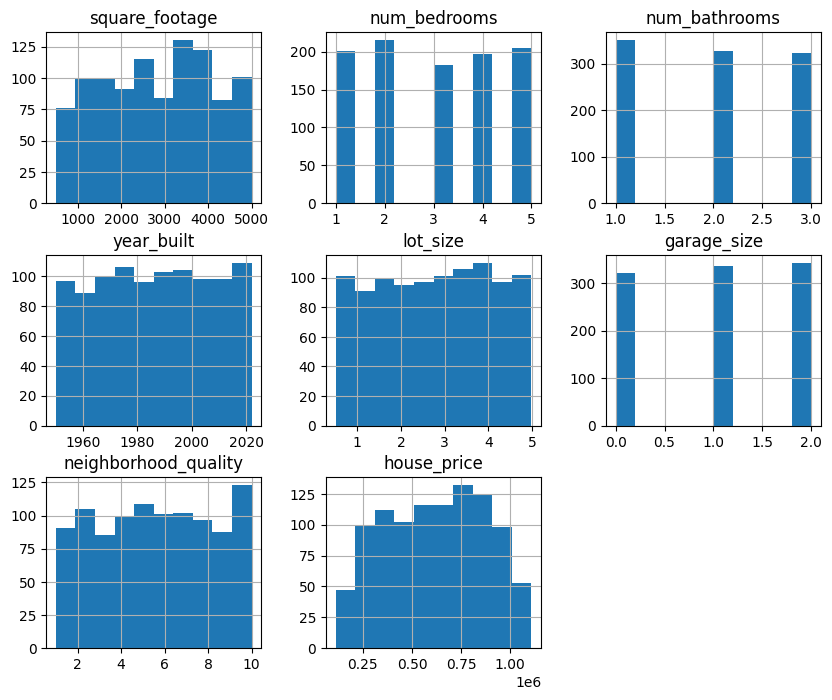

In [16]:
df.hist(figsize=(10,8))
plt.show()

**SCATTER PLOT**

This plot shows the relationship between square footage and house price.
We can observe that as square footage increases, house price also increases,
indicating a positive correlation.

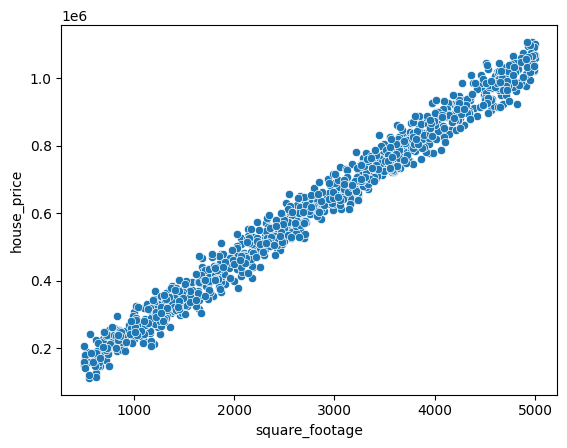

In [19]:
sns.scatterplot(x=df['square_footage'], y=df['house_price'])
plt.show()

**heatmap**

The heatmap displays correlation between all features.
Features with higher correlation values with house_price are more important for prediction.

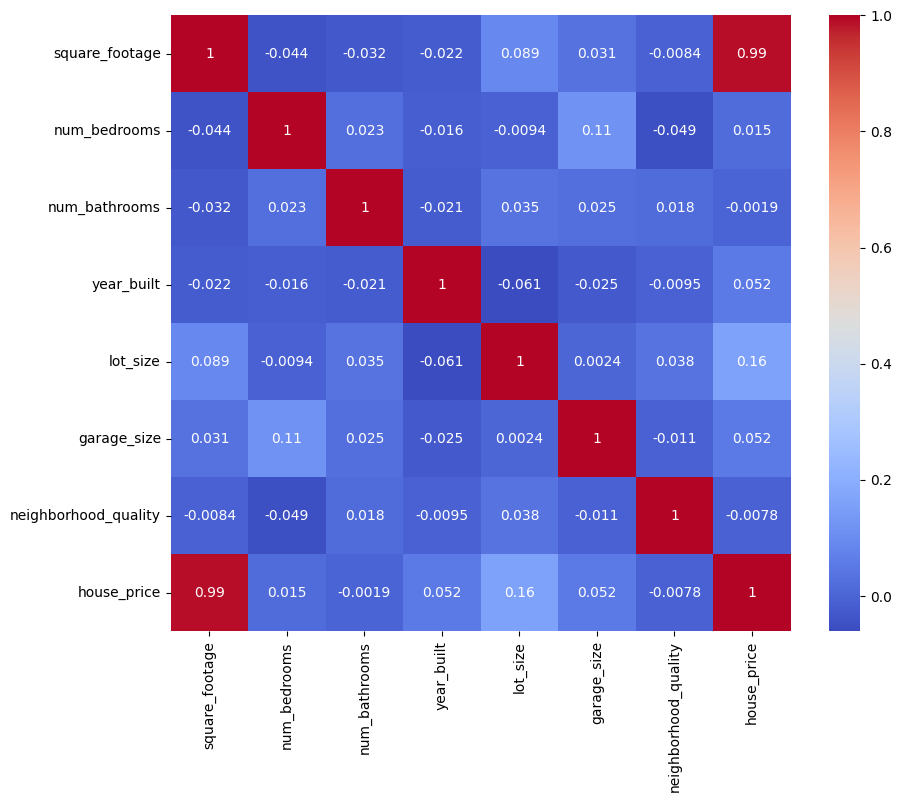

In [21]:
# Correlation heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

The boxplot helps in identifying outliers in the house_price column.
Outliers can negatively impact model performance.

<Axes: ylabel='house_price'>

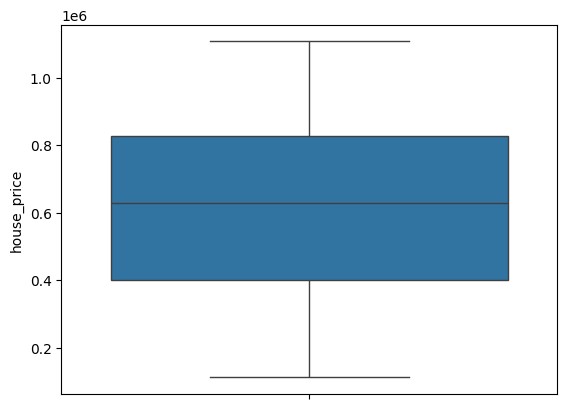

In [22]:
# Boxplot to detect outliers

sns.boxplot(df['house_price'])

In [23]:
# Removing outliers using IQR method

Q1 = df['house_price'].quantile(0.25)
Q3 = df['house_price'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['house_price'] >= Q1 - 1.5*IQR) &
        (df['house_price'] <= Q3 + 1.5*IQR)]

Encoding

Categorical variables are converted into numerical format using one-hot encoding.

In [26]:
# Encoding categorical variables (if any)

df = pd.get_dummies(df, drop_first=True)
df

,square_footage,num_bedrooms,num_bathrooms,year_built,lot_size,garage_size,neighborhood_quality,house_price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [28]:
# Log transformation is applied to reduce skewness and stabilize variance.

df['house_price'] = np.log(df['house_price'])
df

,square_footage,num_bedrooms,num_bathrooms,year_built,lot_size,garage_size,neighborhood_quality,house_price
0,1360,2,1,1981,0.599637,0,5,2.523932
1,4272,3,3,2016,4.753014,1,6,2.624717
2,3592,1,2,2016,3.634823,0,9,2.607453
3,966,1,2,1977,2.730667,1,8,2.513213
4,4926,2,1,1993,4.699073,0,8,2.628747
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,2.599794
996,3179,1,2,1999,2.977123,1,10,2.597886
997,2606,4,2,1962,4.055067,0,2,2.584521
998,4723,5,2,1950,1.930921,0,7,2.623200


In [29]:
# Separating features and target variable

X = df.drop('house_price', axis=1)
y = df['house_price']
df

,square_footage,num_bedrooms,num_bathrooms,year_built,lot_size,garage_size,neighborhood_quality,house_price
0,1360,2,1,1981,0.599637,0,5,2.523932
1,4272,3,3,2016,4.753014,1,6,2.624717
2,3592,1,2,2016,3.634823,0,9,2.607453
3,966,1,2,1977,2.730667,1,8,2.513213
4,4926,2,1,1993,4.699073,0,8,2.628747
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,2.599794
996,3179,1,2,1999,2.977123,1,10,2.597886
997,2606,4,2,1962,4.055067,0,2,2.584521
998,4723,5,2,1950,1.930921,0,7,2.623200


Spliting train and test sets

In [30]:
# Splitting data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Scaling

In [34]:
# Scaling features: Feature scaling ensures that all features contribute equally to the model.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Model Training**



**LINEAR REGRESSION**

Linear Regression models the linear relationship between features and house price.

In [35]:
# Training Linear Regression model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

**KNN REGRESSION**

KNN predicts values based on nearest neighbors in the dataset.

In [36]:
# Training KNN Regression model
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

**EVALUATION METRICS**

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [38]:
def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

**LINEAR REGRESSION RESULTS**

In [39]:
print("Linear Regression:")
evaluate(y_test, y_pred_lr)

Linear Regression:
MAE: 0.007503401586716532
MSE: 8.87013663290954e-05
RMSE: 0.009418140279752442
R2 Score: 0.9373643140253605


**KNN REGRESSION RESULTS**

In [40]:
print("KNN Regression:")
evaluate(y_test, y_pred_knn)

KNN Regression:
MAE: 0.010252706586523618
MSE: 0.00020009529344440169
RMSE: 0.014145504354543236
R2 Score: 0.8587044767868942


## Model Comparison

After evaluating both models:

- Linear Regression has lower error values (MAE = 0.0075, RMSE = 0.0094) compared to KNN Regression.
- KNN Regression has higher error values (MAE = 0.0102, RMSE = 0.0141).
- Linear Regression achieved a higher R² score (0.937) than KNN (0.858).

### Conclusion:
Linear Regression performed better than KNN Regression because:
- It has lower prediction errors.
- It explains more variance in the data (higher R² score).
- The dataset shows a strong linear relationship between features and house price.

Hence, Linear Regression is the best model for this dataset.

